<div class="alert alert-block alert-info" style="margin-top: 20px">

Ms.MRUNALINI (Data Science Trainer)
📧 mrunalini0107@gmail.com
📍 Mumbai–400095

<div class="alert alert-block alert-info" style="margin-top: 20px">

## 📘 Nested Mixed Model Analysis in R — Rats Glycogen Experiment

### Table of contents
1. Nested Design	
   * Different designs:	
   * Example.	
   * Data to be analysed: Description.	
   * Random effects:	
   * Random or fixed effect.	
   * Data to be analysed:Nested	
2. Data Inspection:	
   * Data: Raw	
   * Data structure:	
   * Data summary:	
   * Data visualisation.	
   * Crossed design?	
   * Data visualisation.	
   * Model specification nested design.	
   * Specification matters	
3. Model Diagnostics	
   * Computational performance: Convergence and singularity.	
   * Homoscedasticity test.	
   * Normal distributed resid.	
       * QQplot	
       * Shapiro test	
   * Model diagnostics: all	
   * Influencial observations	
   * DHarma	
4. Summary Statistics	
   * LME4 summary	
   * Random effects	
   * Fixed effects	
   * Fixed effects:	
   * emmeans:	
   * Model selection.	
   * Maximum likelihood comparison.	
   * Summary ModeR2	
   * Summary ModeR2	
   * Power analysis: random effect Rat	
   * Power analysis: fixed effect	
   * Comparing model definitions.	
      * Correct	
      * Wrong	
      * Wrong2	
   * Conclusion	



## 📌 Nested Design Analysis in R (Rats Glycogen Experiment)

#### 👉 Experiment Description
To investigate whether Treatment affects Glycogen concentration, accounting for hierarchical experimental structure.
* Response variable: Glycogen concentration
* Fixed factor: Treatment (3 levels: Treat1, Treat2, Treat3)
* Random factor: Rat nested within Treatment
* Subsampling factor: Liver part (Left, Middle, Right) nested within Rat
* Measurement replication: Two measurements per liver part

#### 👉 Experimental Factors

| Factor     | Type     | Levels | Description                           |
| ---------- | -------- | ------ | ------------------------------------- |
| Treatment  | Fixed    | 3      | Treat1, Treat2, Treat3                |
| Rat        | Random   | 6      | Rats nested within Treatment          |
| Liver Part | Random   | 3      | Left, Middle, Right nested within Rat |
| Replicate  | Residual | 2      | Measurement replicates                |


#### 👉 Structure (Nested Design)
Treatment

 ├── Rat (random, nested in Treatment)

 │    ├── Liver Part (nested in Rat)

 │    │    ├── Measurement replicate

__Total observations:__  $3\; treatments×2 \;rats \;per \;treatment×3 \; liver \; parts×2 \;replicates = 36$


$Glucose \sim Treatment + N(0,sd_{random \; effect} + N(0,sd_{residuals}) \sim Treatment + {\huge \varepsilon} \uparrow$

### 🔹 Install Packages:
    install.packages(c("readxl","ggplot2","lme4","lmerTest",
                    "kableExtra","performance","car",
                    "emmeans","DHARMa","influence.ME"))

In [ ]:
# Install following packages if not already installed
# install.packages("lme4")
# install.packages("readxl")
# install.packages("kableExtra")
# install.packages("lmerTest")
# install.packages("reticulate")
# install.packages("performance")
# install.packages("car")
# install.packages("emmeans")
# install.packages("DHARMa")
# install.packages("influence.ME")
# install.packages("see")

### 🔹Load Required Libraries

In [71]:
# Load libraries
library(readxl)       # Read Excel data
library(ggplot2)      # Visualization
library(kableExtra)   # Tables
library(lme4)         # Mixed model
library(lmerTest)     # p-values for fixed effects
library(performance)  # Model diagnostics
library(car)          # Assumption tests
library(emmeans)      # Estimated marginal means
library(DHARMa)       # Residual diagnostics
library(influence.ME) # Influence diagnostics

### 🔹 Import Data

In [72]:
# Install and load googledrive package
# install.packages("googledrive")

In [73]:
library(googledrive)
library(readxl)

# Authenticate with Google Drive (will open a browser link)
# drive_auth()

# List files in your Drive to confirm access
# drive_find(n_max = 10)

# Download your file to the Colab working directory
# drive_download("Rats2.xlsx", path = "Rats2.xlsx", overwrite = TRUE)

### ✅ Data inspection:
__👉 Data: Raw__
* Rat has two levels but we have 6 rats; not uniquely code.
* liver has three levels but we have 36 part; not uniquely code.

In [74]:
# Read the dataset
#Rats2 <- read_xlsx("Rats2.xlsx")
Rats2 <- readxl::read_xlsx("Rats2.xlsx")

# View first few rows
head(Rats2)

Glycogen,Treatment,Rat,Liver
<dbl>,<dbl>,<dbl>,<dbl>
131,1,1,1
130,1,1,1
131,1,1,2
125,1,1,2
136,1,1,3
142,1,1,3


### ✅ Convert Variables into Factors

👉 This step ensures correct model specification.

In [75]:
# Convert variables into factors (categorical variables)

# Treatment is a fixed effect with 3 levels
Rats2$Treatment <- factor(Rats2$Treatment,
                          labels = c("Treat1", "Treat2", "Treat3"))

# Rat is a random effect
Rats2$Rat <- factor(Rats2$Rat)

# Liver part factor
Rats2$Liver <- factor(Rats2$Liver,
                      labels = c("Left", "Middle", "Right"))

# Unique identifier for each rat (important for nested structure)
# Create a unique ID for each rat
Rats2$Rats_Uniq <- seq_len(nrow(Rats2))

# Convert to factor
Rats2$Rats_Uniq <- factor(Rats2$Rats_Uniq)


# View first few rows
head(Rats2)

Glycogen,Treatment,Rat,Liver,Rats_Uniq
<dbl>,<fct>,<fct>,<fct>,<fct>
131,Treat1,1,Left,1
130,Treat1,1,Left,2
131,Treat1,1,Middle,3
125,Treat1,1,Middle,4
136,Treat1,1,Right,5
142,Treat1,1,Right,6


### ➡️ Interpretation

* Treatment, Rat, Liver are categorical variables.
* Rats_Uniq uniquely identifies each rat.
* This ensures correct nested model specification.

### ✅  Display Data Table

In [76]:
# Load required package
library(readxl)

# Read the Excel file
Rats <- read_xlsx("Rats2.xlsx")

# Convert and save as a text file (tab-delimited by default)
write.table(Rats2, file = "Rats2.txt", sep = "\t", row.names = FALSE, quote = FALSE)

In [77]:
# Display dataset in formatted table
library(kableExtra)
Rats |>
  kbl(format = "markdown")



| Glycogen| Treatment| Rat| Liver|
|--------:|---------:|---:|-----:|
|      131|         1|   1|     1|
|      130|         1|   1|     1|
|      131|         1|   1|     2|
|      125|         1|   1|     2|
|      136|         1|   1|     3|
|      142|         1|   1|     3|
|      150|         1|   2|     1|
|      148|         1|   2|     1|
|      140|         1|   2|     2|
|      143|         1|   2|     2|
|      160|         1|   2|     3|
|      150|         1|   2|     3|
|      157|         2|   1|     1|
|      145|         2|   1|     1|
|      154|         2|   1|     2|
|      142|         2|   1|     2|
|      147|         2|   1|     3|
|      153|         2|   1|     3|
|      151|         2|   2|     1|
|      155|         2|   2|     1|
|      147|         2|   2|     2|
|      147|         2|   2|     2|
|      162|         2|   2|     3|
|      152|         2|   2|     3|
|      134|         3|   1|     1|
|      125|         3|   1|     1|
|      138|       

### ➡️ Interpretation

* Treatment = Fixed categorical variable
* RatID = Random effect nested within Treatment
* LiverID = Random effect nested within Rat


### ✅ Examine Data Structure

In [78]:
# Check structure of dataset
str(Rats)

tibble [36 × 4] (S3: tbl_df/tbl/data.frame)
 $ Glycogen : num [1:36] 131 130 131 125 136 142 150 148 140 143 ...
 $ Treatment: num [1:36] 1 1 1 1 1 1 1 1 1 1 ...
 $ Rat      : num [1:36] 1 1 1 1 1 1 2 2 2 2 ...
 $ Liver    : num [1:36] 1 1 2 2 3 3 1 1 2 2 ...


### ➡️ Interpretation :
__Treatment, Rat and Liver are factors, not numerical.__

### ✅ Convert variables into factors systematically

In [79]:
# Treatment: fixed effect with 3 levels
Rats$Treatment <- factor(Rats$Treatment,labels = c("Treat1", "Treat2", "Treat3"))

# Rat: unique identifier for each rat
Rats$Rat <- factor(Rats$Rat)

# Liver: categorical variable with 3 levels
Rats$Liver <- factor(Rats$Liver, labels = c("Left", "Middle", "Right"))

# Inspect the structure of the dataset
str(Rats)


tibble [36 × 4] (S3: tbl_df/tbl/data.frame)
 $ Glycogen : num [1:36] 131 130 131 125 136 142 150 148 140 143 ...
 $ Treatment: Factor w/ 3 levels "Treat1","Treat2",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ Rat      : Factor w/ 2 levels "1","2": 1 1 1 1 1 1 2 2 2 2 ...
 $ Liver    : Factor w/ 3 levels "Left","Middle",..: 1 1 2 2 3 3 1 1 2 2 ...


### ✅  Summary Statistics

In [80]:
# Summary statistics
summary(Rats)

    Glycogen      Treatment  Rat       Liver   
 Min.   :125.0   Treat1:12   1:18   Left  :12  
 1st Qu.:135.8   Treat2:12   2:18   Middle:12  
 Median :141.0   Treat3:12          Right :12  
 Mean   :142.2                                 
 3rd Qu.:150.0                                 
 Max.   :162.0                                 

### ➡️ Interpretation

This provides:

* Minimum glycogen value
* Maximum glycogen value
* Mean glycogen level
* Distribution across treatments

This gives a general understanding of variability.

This looks like a crossed factorial design, all combinations are measured.

### ✅ Data Visualization: Treatment Effect

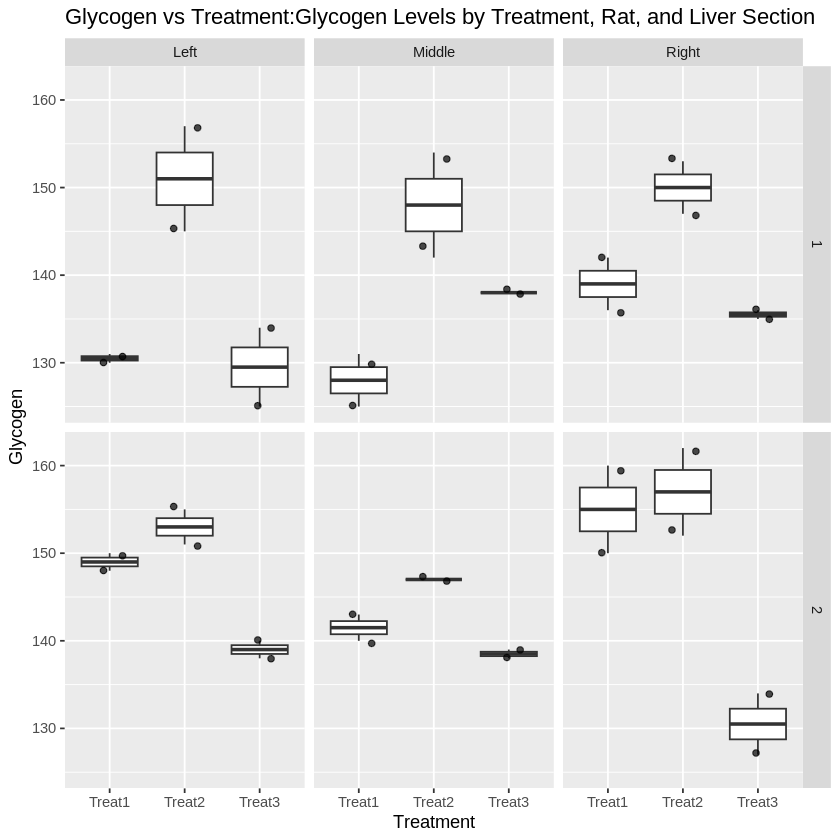

In [81]:
library(ggplot2)

# Boxplot of glycogen vs treatment, faceted by rat and liver
ggplot(Rats, aes(x = Treatment, y = Glycogen)) +
  geom_boxplot() +
  geom_point(position = position_jitter(width = 0.2), alpha = 0.7) +
  facet_grid(Rat ~ Liver) +
  labs(
    title = "Glycogen vs Treatment:Glycogen Levels by Treatment, Rat, and Liver Section",
    x = "Treatment",
    y = "Glycogen"
  )


### ➡️ Interpretation

Shows:

* Variation of Glycogen across treatments
* Overlap indicates possible weak treatment effect

### ✅ Check Nested Structure

👉__Crossed design?__

__The plot is an inaccurate representation; experiment has 6 rats, not 2.__


In [82]:
# Inspect the Rat variable
Rats$Rat

# Cross-tabulation of Treatment and Rat
with(Rats, table(Treatment, Rat))

[1] 1 1 1 1 1 1 2 2 2 2 2 2 1 1 1 1 1 1 2 2 2 2 2 2 1 1 1 1 1 1 2 2 2 2 2 2
Levels: 1 2

         Rat
Treatment 1 2
   Treat1 6 6
   Treat2 6 6
   Treat3 6 6

👉 __To generate the cross-tabulation: Give the rats a unique identifier__

In [83]:
# Create a unique identifier for each rat (6 rats total)
Rats2$Rats_Uniq <- rep(1:6, each = 6)   # each rat has 6 observations

# Inspect the Rat variable
Rats2$Rats_Uniq

# Cross-tabulation of Treatment and Rats_Uniq
with(Rats2, table(Treatment, Rats_Uniq))

[1] 1 1 1 1 1 1 2 2 2 2 2 2 3 3 3 3 3 3 4 4 4 4 4 4 5 5 5 5 5 5 6 6 6 6 6 6

         Rats_Uniq
Treatment 1 2 3 4 5 6
   Treat1 6 6 0 0 0 0
   Treat2 0 0 6 6 0 0
   Treat3 0 0 0 0 6 6

 ### ✅ Visualize Nested Structure

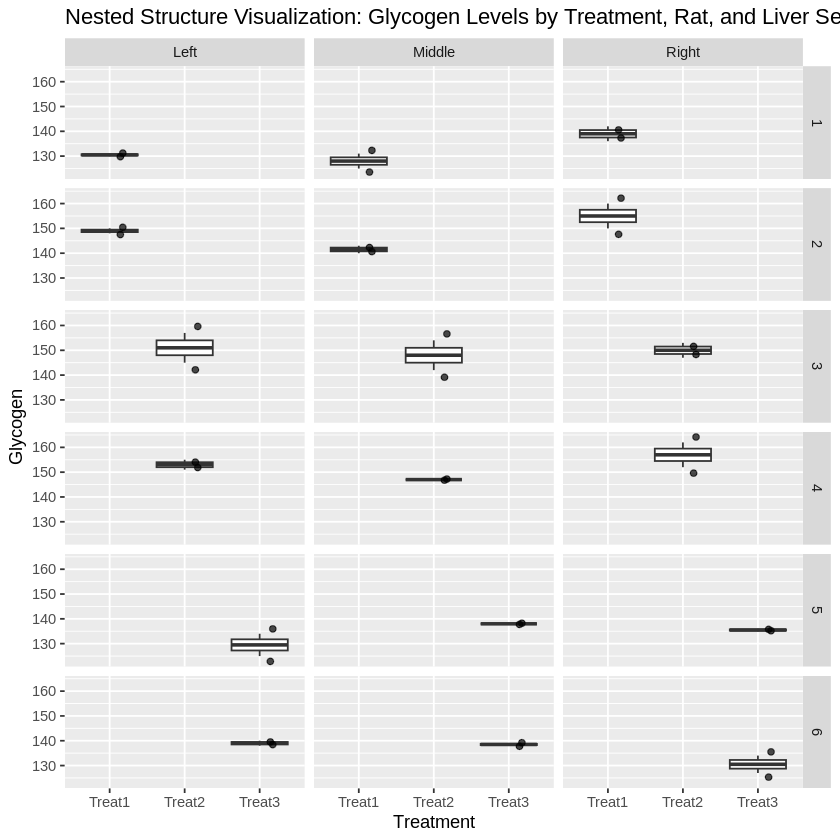

In [84]:
library(ggplot2)

# Boxplot of glycogen vs treatment, faceted by rat and liver
ggplot(Rats2, aes(x = Treatment, y = Glycogen)) +
  geom_boxplot() +
  geom_point(position = position_jitter(width = 0.2), alpha = 0.7) +
  facet_grid(Rats_Uniq ~ Liver) +
  labs(
    title = "Nested Structure Visualization: Glycogen Levels by Treatment, Rat, and Liver Section",
    x = "Treatment",
    y = "Glycogen"
  )


### ➡️ Interpretation

Confirms hierarchical nesting:

__Treatment → Rat → Liver__

### ✅ Visualization: Glycogen variation across Rats

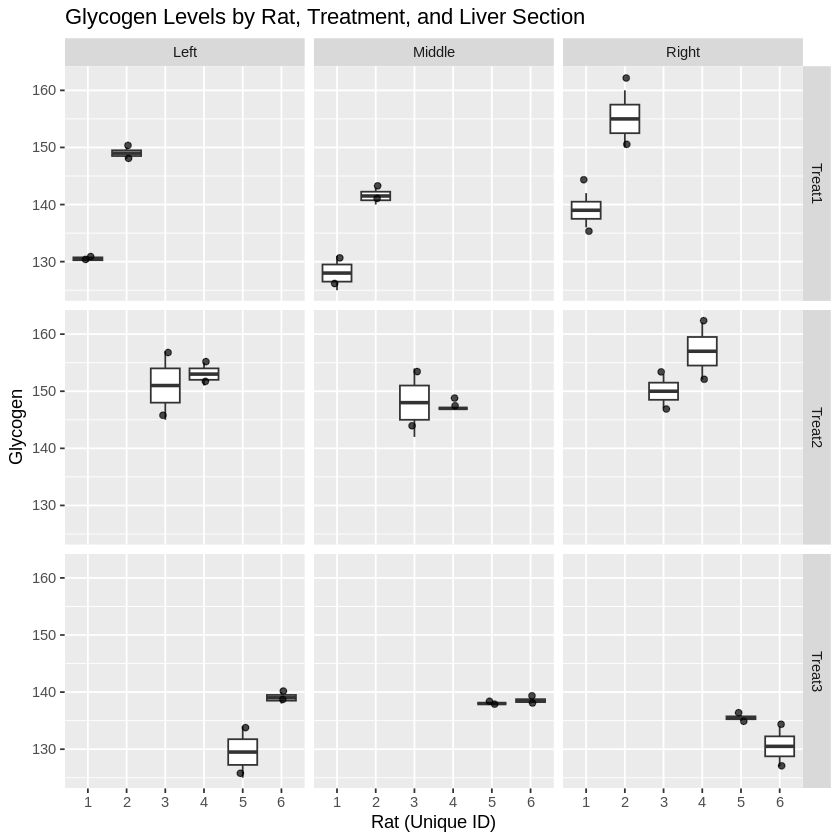

In [85]:
library(ggplot2)

# Ensure Rats_Uniq is a factor (categorical)
Rats2$Rats_Uniq <- factor(Rats2$Rats_Uniq)

# Plot glycogen levels by rat, faceted by treatment and liver
ggplot(Rats2, aes(x = Rats_Uniq, y = Glycogen)) +
  geom_boxplot() +
  geom_point(position = position_jitter(width = 0.2), alpha = 0.7) +
  facet_grid(Treatment ~ Liver) +
  labs(
    title = "Glycogen Levels by Rat, Treatment, and Liver Section",
    x = "Rat (Unique ID)",
    y = "Glycogen"
  )


### ✅ Model specification:  Mixed Effects Model (Nested Model)

👉 A linear mixed-effects model was fitted to analyse the effect of Treatment on Glycogen concentration, while accounting for the nested experimental structure.

Treatment was included as a fixed effect, and random intercepts were included for:

🔹 Rat nested within Treatment

🔹 Liver part nested within Rat and Treatment

This model accounts for variability between rats and between liver parts within rats

#### 📐 Mathematical Model Formulation:

Let
* $Y_{ijkl}$ → Glycogen measurement
* $i$ → Treatment (i = 1,2,3)
* $j$ → Rat nested within Treatment
* $k$ → Liver nested within Rat and Treatment
* $l$ → replicate measurement

👉 __The model is__ : $Y_{ijkl}=μ+α_i+b_{j(i)}+c_{k(j(i))}+ε_{ijkl}$

#### 👉 Model Components Explanation:
Where:
* $μ$ → overall mean Glycogen level
* $α_i​$ → fixed effect of Treatment $i$
* $b_{j(i)}∼N(0,σ_{Rat}^2​)$ → random effect of Rat nested within Treatment
* $c_{k(j(i))}∼N(0,σ_{Liver}^2​)$ → random effect of Liver nested within Rat and Treatment
* $ε_{ijkl​}∼N(0,σ^2)$ → residual error

$Glycogen∼Treatment+(1∣Treatment:Rat)+(1∣Treatment:Rat:Liver)+ε$

 __👉 Model  Representation__

Treatment (Fixed)

└── Rat (Random, nested in Treatment)

  └── Liver (Random, nested in Rat and Treatment)

    └── Measurement error (Residual)

In [86]:
# Load required library
library(lme4)
library(lmerTest)   # Provides p-values for fixed effects

In [87]:
# Fit nested mixed effects model
ModelR <- lmer(Glycogen ~ Treatment +
               (1|Treatment:Rat) +
               (1|Treatment:Rat:Liver),
               data = Rats)


🔹 __$(1 | Treatment:Rat)$:__ each Rat is allowed to have its own random intercept within each Treatment

🔹 __$(1|Treatment:Rat:Liver)$:__ each Liver (within each Rat and each Treatment) is allowed to have its own random intercept.


### ➡️ Interpretation

This model includes:

🔹 Treatment as a fixed effect

🔹 Rat nested within Treatment as a random effect

🔹 Liver nested within Rat and Treatment as a random effect

🔹 Residual error representing measurement variability

* Total observations: 36
* Total rats: 6
* Total liver units: 18

### ✅ LME4 Summary:

In [88]:
# Model summary
summary(ModelR)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: Glycogen ~ Treatment + (1 | Treatment:Rat) + (1 | Treatment:Rat:Liver)
   Data: Rats

REML criterion at convergence: 219.6

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-1.48212 -0.47263  0.03062  0.42934  1.82935 

Random effects:
 Groups              Name        Variance Std.Dev.
 Treatment:Rat:Liver (Intercept) 14.17    3.764   
 Treatment:Rat       (Intercept) 36.06    6.005   
 Residual                        21.17    4.601   
Number of obs: 36, groups:  Treatment:Rat:Liver, 18; Treatment:Rat, 6

Fixed effects:
                Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)      140.500      4.707   3.000  29.848 8.26e-05 ***
TreatmentTreat2   10.500      6.657   3.000   1.577    0.213    
TreatmentTreat3   -5.333      6.657   3.000  -0.801    0.482    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
     

### ✔ 1. Residual Diagnostics
Scaled residuals:
* Min = -1.48
* 1Q  = -0.47
* Median = 0.03
* 3Q  = 0.43
* Max = 1.83

#### ➡️ Interpretation
* Residuals are approximately symmetric around zero.
* Median is close to zero (0.03), indicating good model fit.
* No extreme outliers are present.
* This suggests that the model assumptions are reasonably satisfied.

### ✔ 2. Random Effects Interpretation
__Random effects:__
  
| Groups              | Variance | Std. Dev. |
| ------------------- | -------: | --------: |
| Treatment:Rat:Liver |    14.17 |     3.764 |
| Treatment:Rat       |    36.06 |     6.005 |
| Residual            |    21.17 |     4.601 |

These represent variance components at different levels.

### 🔹 (a) Rat nested within Treatment

* Variance = 36.06
* Standard deviation = 6.005

#### ➡️ Interpretation

This is the largest variance component, meaning:
* There is substantial biological variability between rats.
* Different rats naturally have different glycogen levels.
* Rat-to-rat variability is an important source of variation.

__Conclusion:__ Rat is an important random effect and must be included in the model.

### 🔹 (b) Liver nested within Rat

* Variance = 14.17
* Standard deviation = 3.764

#### ➡️ Interpretation

* This represents variability between liver parts within the same rat.
* This variability may be due to:
  * Biological variation across liver regions
  * Measurement variability

__Conclusion:__ Liver subsampling introduces moderate variability.

### 🔹 (c) Residual Variance

* Variance = 21.17
* Standard deviation = 4.601

#### ➡️ Interpretation

This represents:
* Measurement error
* Unexplained variability

__Conclusion:__ Some variability exists beyond rat and liver differences.

### ✔ 3. Fixed Effects Interpretation

__Fixed effects:__
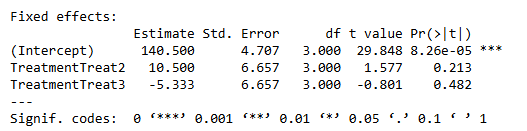

__Significance codes:__

* *** → Highly significant (p < 0.001)
* ** → Significant (p < 0.01)
* → Significant (p < 0.05)
* NS → Not significant (p ≥ 0.05)

### 🔹 (a) Intercept

* Estimate = 140.500
* p-value = 0.0000826 (<0.001)

#### ➡️ Interpretation

This represents the mean glycogen level for the reference group (Treat1).

__Conclusion:__ The mean glycogen level for Treat1 is approximately 140.5 units, and this is highly statistically significant.

### 🔹 (b) Treatment 2 Effect

* Estimate = 10.500
* p-value = 0.213 (>0.05)

#### ➡️ Interpretation

* Treatment 2 increases glycogen level by approximately 10.5 units compared to Treat1.
* However, the p-value is greater than 0.05.

__Conclusion:__
* This increase is not statistically significant.
* There is insufficient evidence to conclude that Treat2 differs from Treat1

### 🔹 (c) Treatment 3 Effect

* Estimate = −5.333
* p-value = 0.482 (>0.05)

#### ➡️ Interpretation

* Treatment 3 decreases glycogen level by approximately 5.33 units compared to Treat1.
* However, this difference is not statistically significant.

__Conclusion:__ There is no evidence that Treat3 differs from Treat1.


### ✔ 4. Overall Treatment Effect Conclusion

Since both treatment effects have:

* p-value > 0.05

__👉 Conclusion:__
* Treatment does NOT have a statistically significant effect on glycogen concentration.
* Observed differences may be due to random variation.

### ✅ ANOVA Test
👉 This ANOVA tests

__The null hypothesis:__ $H_0​:μ_{Treat1}​=μ_{Treat2}​=μ_{Treat3}​$

__Alternative hypothesis:__ $H_1​$:At least one treatment mean is different

This determines whether treatment has a significant effect on glycogen concentration.

In [89]:
anova(ModelR)

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
Treatment,123.9927,61.99634,2,3.000001,2.928961,0.1970988


### ➡️ Interpretation of F-value

__F value = 2.928961__

* The variation between treatment means is about 2.93 times the residual variation.
* However, this difference must be statistically significant to conclude treatment effect.

### ➡️ Interpretation of p-value

__p-value = 0.1970988__

Compare with significance level: $α=0.05$

Since: $0.197>0.05$

__Fail to reject the null hypothesis.__

__Conclusion__

* There is no statistically significant effect of treatment on glycogen concentration.
* The observed differences between treatment means may be due to random variability rather than true treatment effect.

#### ➡️ Degrees of Freedom Interpretation

Numerator DF = 2 → corresponds to 3 treatments − 1

Denominator DF = 3 → reflects variability between rats within treatments

__👉 This confirms correct nested structure analysis.__

### ✅ Incorrect Model Specification in Nested Design

In [90]:
# WRONG model specification:
# Treatment is not included as a fixed effect.
# Instead, Treatment is incorrectly treated as a random effect
# due to the nesting structure Treatment/Rat/Liver.

ModelR_wrong <- lmer(
  Glycogen ~ 1 +                  # Only intercept is included as fixed effect
  (1 | Treatment/Rat/Liver),     # Nested random effects: Liver within Rat within Treatment
  data = Rats)

➡️ Here treatment is seen as a random effect it is shorthand for:

$(1|Treatment) + (1|Treatment:Rat) + (1|Treatment:Rat:Liver)$

Can be used however if unique rats ID are used.


#### ➡️ Fixed Effect Part: $Glycogen ~ 1$
This includes only:

* Overall mean glycogen level (intercept)
* No treatment effect is estimated

This means:

❌ The model does NOT test whether Treatment affects Glycogen


#### ➡️ Random Effect Part: $(1 | Treatment/Rat/Liver)$
This expands internally to:

$(1 | Treatment) +$

$(1 | Treatment:Rat) +$

$(1 | Treatment:Rat:Liver)$

This means:

* Treatment is treated as a random effect ❌
* Rat nested within Treatment is random ✔
* Liver nested within Rat is random ✔

#### ➡️ Why This Model is WRONG

Because Treatment is the main factor of interest and should be treated as a fixed effect.

This incorrect model assumes:

* Treatments are randomly sampled from a population
* We are NOT interested in comparing treatments

But in this experiment:

* We want to compare Treat1, Treat2, Treat3
* Therefore Treatment must be fixed


### ✅ Nested Mixed Model Using Unique Rat ID

👉 This specification is correct only when Rat IDs are unique across all treatments.

In [91]:
# Mixed-effects model with Treatment as fixed effect
# and Liver nested within Rat as random effect

ModelR_wrong2 <- lmer(
  Glycogen ~ Treatment +     # Fixed effect: Treatment (factor of scientific interest)
  (1 | Rat/Liver),           # Random effects: Liver nested within Rat
  data = Rats)


boundary (singular) fit: see help('isSingular')



#### ➡️ Fixed Effect: $Treatment$
* Treatment is correctly specified as a fixed effect
* This allows comparison of Treat1, Treat2, and Treat3
* The model tests whether treatment significantly affects glycogen concentration

#### ➡️ Random Effect Structure: $(1 | Rat/Liver)$
This expands internally to: $(1 | Rat) + (1 | Rat:Liver)$

This means:
* Random intercept for each Rat
* Random intercept for each Liver part nested within Rat

####  ➡️ When This Specification is Correct)

This model is correct ONLY IF: Rat IDs are unique across all treatments

__* Example of correct unique Rat IDs:__ Rat1, Rat2, Rat3, Rat4, Rat5, Rat6

__* Example of incorrect Rat IDs:__

    Treatment 1: Rat1, Rat2

    Treatment 2: Rat1, Rat2

    Treatment 3: Rat1, Rat2

In the incorrect case, Rat1 appears in multiple treatments, causing model confusion.


####  ➡️ Why Unique Rat ID Matters

If Rat IDs are unique, then:
Rat already contains Treatment information

So this: $(1 | Rat)$

is equivalent to: $(1 | Treatment:Rat)$


#### ➡️ Equivalent Correct Model (when Rat IDs are NOT unique)

    ModelR_correct <- lmer(Glycogen ~ Treatment + (1 | Treatment:Rat) + (1 | Treatment:Rat:Liver), data = Rats)

### ➡️  Model Interpretation

This model estimates:

* Treatment effect (fixed effect)
* Random variation between rats
* Random variation between liver parts
* Residual measurement error

### ✅ Model Diagnostics for Mixed Effects Model

👉 Model diagnostics help verify whether the fitted mixed model is reliable and satisfies model assumptions.

👉 We check:

1. Convergence
2. Singularity
3. Homoscedasticity (constant variance)
4. Residual behavior

In [92]:
# Load performance package for diagnostic checks
library(performance)

#### 👉 1. Check Model Convergence

In [93]:
# Check whether the model converged properly
performance::check_convergence(ModelR)

[1] TRUE
attr(,"gradient")
[1] 3.977855e-07

### ➡️ Interpretation

This function verifies whether the model estimation algorithm successfully converged.


➡️ 1. Expected Output (Good Model)

**Model converged successfully.**

Meaning

* The optimization algorithm found stable parameter estimates
* Model results are reliable

➡️ 2. If convergence warning appears

**Model failed to converge**

Meaning:

* Model estimates may not be reliable
* Model may be over-complex
* Data may be insufficient

In [94]:
# Inspect gradient attribute
attr(check_convergence(ModelR), "gradient")


[1] 3.977855e-07

#### 👉 2. Check Model Singularity

In [95]:
# Check for singularity (overfitting or redundant random effects)
performance::check_singularity(ModelR)


[1] FALSE

### ➡️ Interpretation

Singularity occurs when variance of a random effect is close to zero.

➡️ 1. Expected Output (Good Model)

**Model is not singular.**

Meaning:
* Random effects structure is appropriate
* No redundant random effects


➡️ 2. Problematic Output

**Model is singular.**

Meaning:
* Some random effects may not contribute meaningful variability
* Model may be over-parameterized

#### 👉 3. Check Homoscedasticity (Constant Variance)

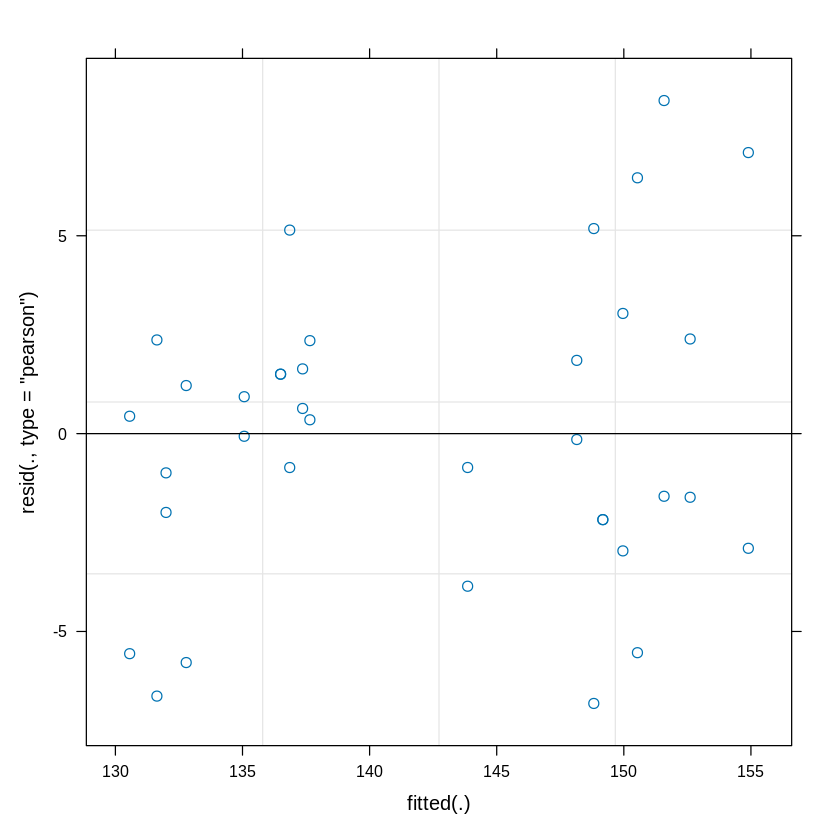

In [96]:
# Plot residuals vs fitted values
plot(ModelR)


### ➡️ Interpretation

This produces: __Residuals vs Fitted plot__

__➡️ Good Model (Assumption satisfied)__

__➡️ Residuals should:__

    • Be randomly scattered

    • Show no clear pattern

    • Have constant spread

➡️ Meaning:

__👉 Homoscedasticity assumption is satisfied.__

#### 👉 4. Levene’s Test for Homogeneity of Variance

Levene’s test is used to check whether the variance of residuals is equal across treatment groups (homoscedasticity assumption).

#### Hypotheses:

* __Null hypothesis (H₀):__ The residual variances are equal across all treatment groups.
* __Alternative hypothesis (H₁):__ At least one treatment group has different residual variance.

In [97]:
# Load required library
library(car)

# Perform Levene's Test on model residuals across Treatment groups
car::leveneTest(residuals(ModelR) ~ Rats$Treatment)


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,1.45327,0.2483797
,33,NA,NA


### ➡️ Interpretation of Levene’s Test Output
Levene’s test was performed to assess the homogeneity of variance assumption for the residuals of the mixed-effects model across the different treatment groups.

The test evaluates whether the variance of residuals is equal for all treatments.

Output Summary:

| Source            | Df | F value | Pr(>F)    |
| ----------------- | -- | ------- | --------- |
| Treatment (group) | 2  | 1.45327 | 0.2483797 |
| Residuals         | 33 | NA      | NA        |

➡️ __Interpretation of p-value__

__p-value = 0.2483797__

Compare with significance level: $α=0.05$

Since: $0.248>0.05$

__we fail to reject the null hypothesis.__


#### ➡️ Statistical Conclusion

There is no statistically significant difference in residual variances across treatment groups.

This means:

* Variance of residuals is approximately equal across treatments.
* The homoscedasticity (constant variance) assumption is satisfied.

#### ➡️ Model Adequacy Conclusion

Since the homogeneity of variance assumption is satisfied:
* The mixed-effects model assumptions are valid.
* The model results and statistical inferences are reliable.


__👉 Levene’s test showed no significant difference in residual variances across treatments (F(2,33) = 1.45, p = 0.248). Since p > 0.05, the homoscedasticity assumption is satisfied. Therefore, the mixed-effects model assumptions are valid.__

### ✅ Check Normality of Residuals using Q–Q Plot

👉 The __Q–Q (Quantile–Quantile) plot__ is used to verify whether the residuals from the mixed-effects model follow a normal distribution.



[1] 11 23

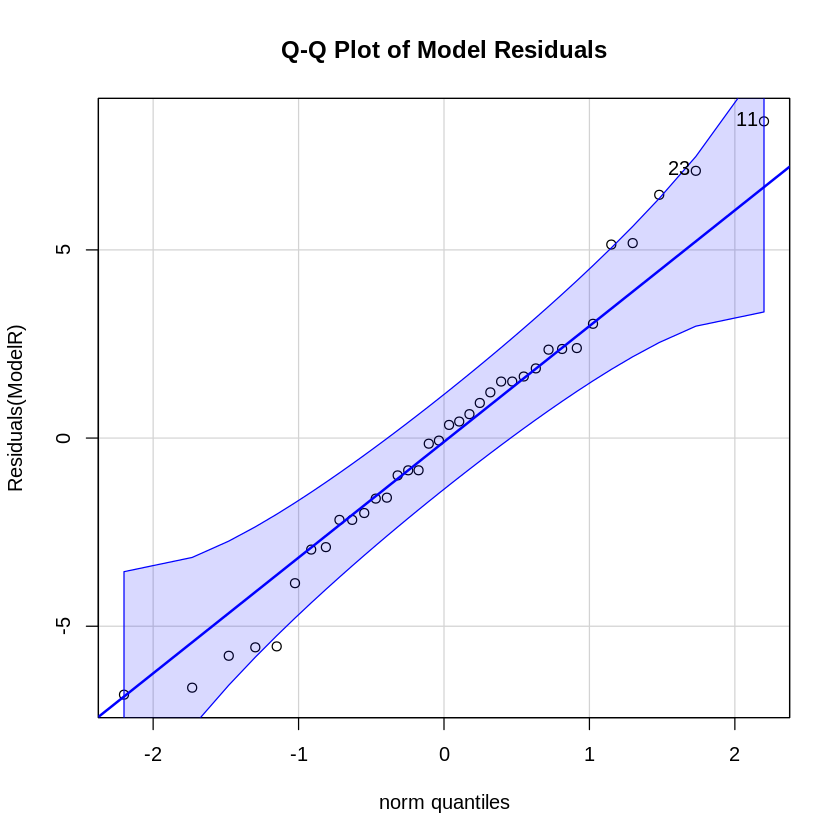

In [98]:
# Load required library
library(car)

# Create Q-Q plot of residuals from the mixed-effects model
car::qqPlot(
  resid(ModelR),                # Extract residuals from the model
  main = "Q-Q Plot of Model Residuals",
  ylab = "Residuals(ModelR)"
)


### ➡️ Interpretation

This plot checks the normality assumption of residuals, which is required for valid statistical inference in linear mixed models.

#### ➡️ Interpret the Q–Q Plot

__➡️ Case 1: Residuals are Normally Distributed (Good Model)__

If the points:

* Lie approximately on the straight reference line
* Show no strong deviation

__👉 Conclusion:__
* Residuals are normally distributed.
* Normality assumption is satisfied.

__➡️ Case 2: Residuals are NOT Normally Distributed (Problem)__

If the points:

* Deviate strongly from the line
* Show curved pattern or extreme outliers

__👉 Conclusion:__
* Residuals are not normally distributed.
* Normality assumption may be violated.

### ✅ Additional Normality Test (Formal Test): Shapiro Test

__Hypotheses:__

* __Null hypothesis (H₀):__ Residuals are normally distributed.
* __Alternative hypothesis (H₁):__ Residuals are not normally distributed.

In [99]:
shapiro.test(resid(ModelR))


	Shapiro-Wilk normality test

data:  resid(ModelR)
W = 0.97628, p-value = 0.6193


### ➡️ Interpretation of Shapiro–Wilk Normality Test

The Shapiro–Wilk test was performed to assess whether the residuals from the mixed-effects model are normally distributed.

__➡️ Interpretation of p-value__

__p-value = 0.6193__

Compare with significance level: $α=0.05$

Since: $0.6193>0.05$

__we fail to reject the null hypothesis.__

__➡️ Statistical Conclusion__

There is no evidence to suggest that residuals deviate from normality.

This means:
* Residuals are normally distributed
* Normality assumption of the mixed-effects model is satisfied

__➡️ Interpretation of W Statistic__

__W = 0.97628__
* The W value ranges from 0 to 1
* Values close to 1 indicate normal distribution

Since 0.97628 is close to 1, this confirms good normality.

__➡️ Model Adequacy Conclusion__

* Since the residuals are normally distributed:
* The mixed-effects model assumptions are satisfied
* The model results are reliable
* Statistical inference (p-values, confidence intervals) is valid


__👉 The Shapiro–Wilk test showed that residuals are normally distributed (W = 0.976, p = 0.619). Since p > 0.05, the normality assumption is satisfied. Therefore, the mixed-effects model is appropriate.__

### ✅ Model Diagnostics: Comprehensive Check of Mixed Effects Model

👉 This function performs a full diagnostic check of the mixed-effects model, including:

✔ Normality of residuals

✔ Homoscedasticity (constant variance)

✔ Linearity

✔ Outliers

✔ Influential observations

In [100]:
# Install required packages if not already installed
#install.packages("performance")
#install.packages("see")

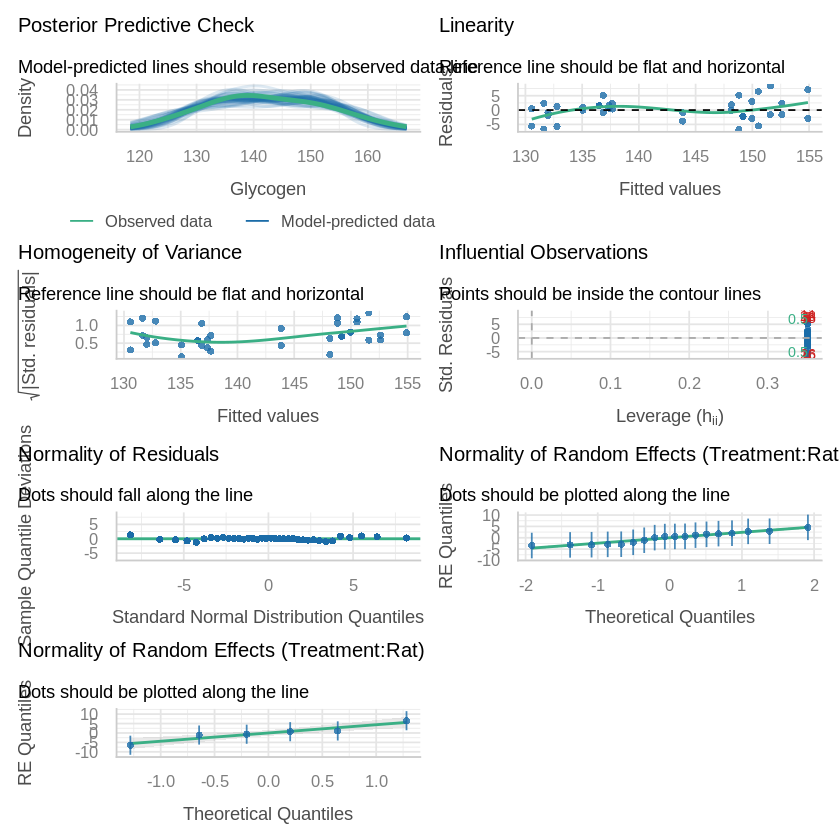

In [101]:
# Load libraries
library(performance)
library(see)

# Perform comprehensive diagnostic checks for the mixed-effects model
performance::check_model(
  ModelR   # Mixed-effects model object
)

### ➡️ Interpretation

This command produces multiple diagnostic plots, typically including:

* Residuals vs Fitted plot
* Normal Q–Q plot
* Scale–Location plot
* Residual distribution plot
* Leverage and influence plot

These plots help verify whether model assumptions are satisfied.

#### ➡️ Interpretation of Diagnostic Plots
__➡️ 1. Residuals vs Fitted Plot (Linearity and Homoscedasticity)__

__Good Model__
* Residuals randomly scattered around zero
* No clear pattern or funnel shape

__👉 Conclusion:__ Linearity and homoscedasticity assumptions are satisfied.

__➡️ 2. Normal Q–Q Plot (Normality)__

Good Model

* Points lie close to the reference line

__👉 Conclusion:__ Residuals are normally distributed.

__➡️ 3. Scale–Location Plot (Constant Variance)__

Good Model

* Horizontal band of points
* No increasing or decreasing trend

__Conclusion:__ Variance is constant.

__➡️4. Residual Distribution Plot__

Good Model

* Residuals follow approximately normal distribution
* Bell-shaped curve

__👉 Conclusion:__ Normality assumption satisfied.

__➡️ 5. Influence and Leverage Plot__

Good Model

* No extreme influential points

__👉 Conclusion:__ No observation unduly influences the model.

__➡️ Overall Diagnostic Conclusion__

__👉 The diagnostic plots obtained from check_model() indicated that residuals were normally distributed and showed constant variance. No significant outliers or influential observations were present. The model assumptions of normality, linearity, and homoscedasticity were satisfied. Therefore, the mixed-effects model is appropriate and valid.__

### ✅ Influential Observations Diagnostics (Cook’s Distance)

👉 This analysis identifies observations that have a strong influence on the fitted mixed-effects model.

This code:

* Calculates Cook’s distance for each observation
* Identifies observations that strongly influence model estimates
* Helps verify model robustness

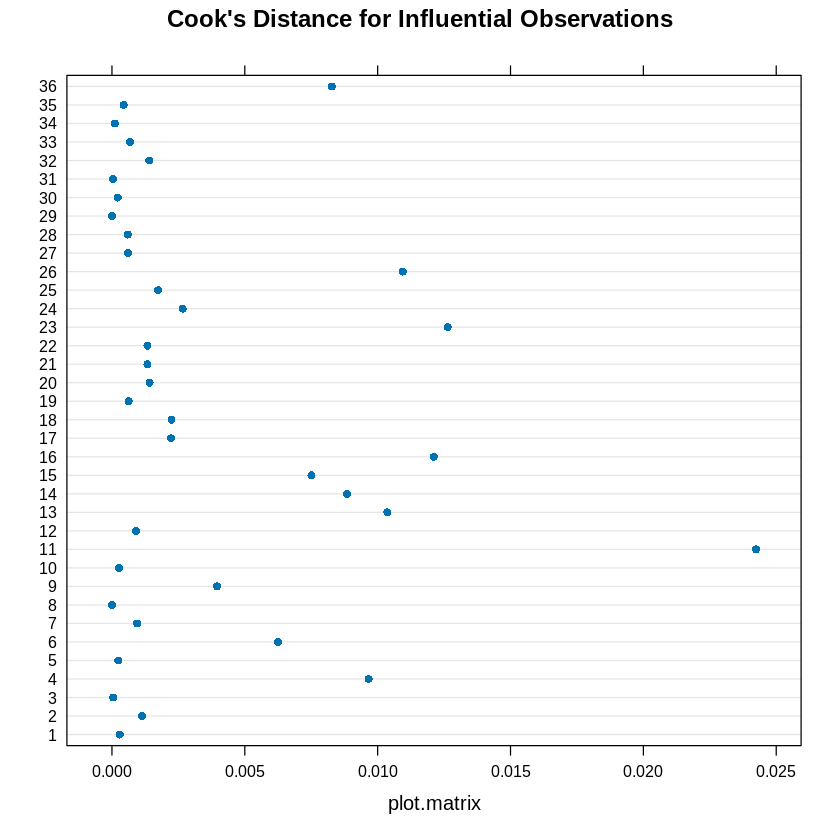

In [102]:
# Load required library for influence diagnostics in mixed models
library(influence.ME)

# Compute influence measures for each observation
inf <- influence(
  ModelR,                   # Mixed-effects model object
  obs = TRUE                # Calculate influence at observation level
)

# Plot Cook's distance to identify influential observations
plot(
  inf,
  which = "cook",            # Specify Cook's distance plot
  main = "Cook's Distance for Influential Observations"
)


### ➡️ Interpretation

#### ➡️ Interpret Cook’s Distance Plot

Cook’s distance measures how much model estimates change when an observation is removed.

__➡️ Rule of Thumb__

An observation is considered influential if:

$Cook’s \;distance>0.5$

or more conservatively,

$Cook’s\; distance>1$

__➡️ Case 1: No Influential Observations (Good Model)__

If all points lie below 0.5:

#### 👉 Conclusion:

* No observation has excessive influence
* Model is stable and reliable

__➡️ Case 2: Influential Observations Present (Problem)__

If some points exceed 0.5:

#### 👉 Conclusion:

* Those observations strongly affect model estimates
* Further investigation is needed

__➡️ Observations from the Plot__

The Cook’s distance values for all observations range approximately between 0.000 and 0.025.

None of the observations exceed the commonly used threshold value of 0.5.

All points lie very close to zero, indicating minimal influence of individual observations.

__➡️ Statistical Interpretation__

Since all Cook’s distance values are: $Cook’s \;distance< 0.5$

this indicates that:

* No observation has excessive influence on the model.
* No single observation significantly affects the model estimates.
* The model is stable and robust.

__➡️ Model Adequacy Conclusion__

The absence of influential observations confirms that:

* The fitted mixed-effects model is reliable.
* The parameter estimates are not driven by any extreme or unusual observations.
* The model results can be safely interpreted.

__👉 The Cook’s distance plot showed that all values were below 0.5. This indicates that no influential observations are present. Therefore, the mixed-effects model is stable and reliable.__

### ✅ Model Diagnostics Using DHARMa (Residual Diagnostics)

👉 The __DHARMa package__ is used to evaluate the goodness-of-fit of mixed-effects models by generating simulated residuals. These residuals help check whether model assumptions are satisfied.

👉 The `simulateResiduals()` function creates standardized residuals, and `plot()` produces diagnostic plots.

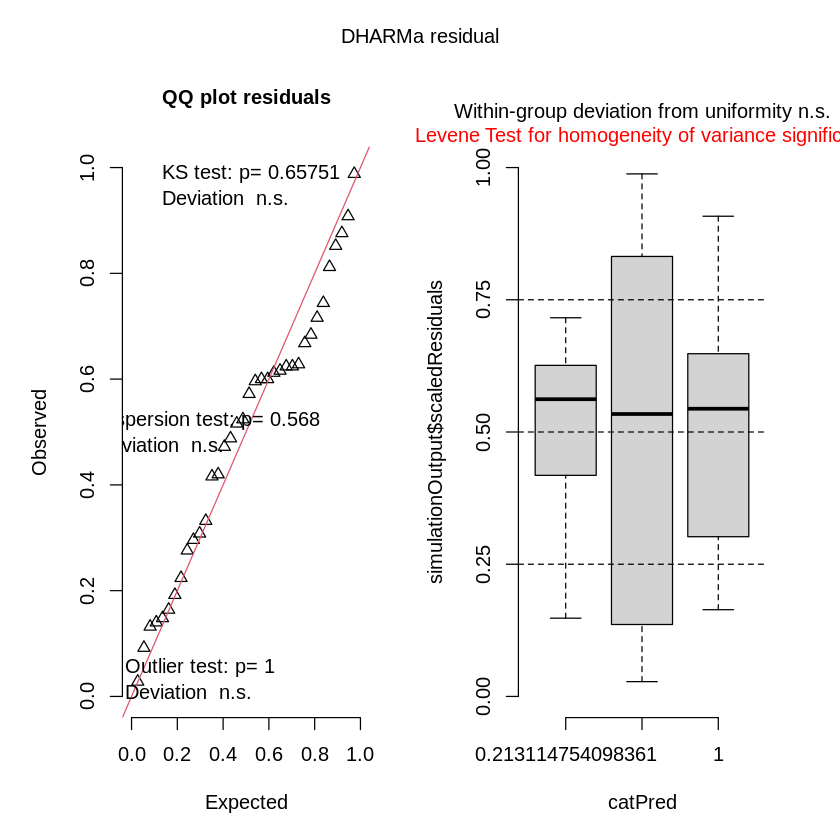

In [103]:
# Load the DHARMa package for residual diagnostics of mixed models
library(DHARMa)

# Simulate scaled residuals from the fitted mixed-effects model (ModelR)
# plot = FALSE prevents automatic plotting so we can control plotting manually
SimRes <- simulateResiduals(ModelR, plot = FALSE)

# Plot the diagnostic graphs for residual analysis
plot(SimRes)


### ➡️ Interpretation

#### ➡️ Diagnostic Plots Produced

The plot typically contains four panels:

* Residual vs Predicted Plot
* Quantile–Quantile (QQ) Plot
* Histogram of Residuals
* Residual vs Predictor (or Index) Plot

__➡️ Statistical Interpretation__

The DHARMa residual diagnostics help evaluate the following assumptions:

__1. Uniformity of Residuals (QQ Plot)__
* If points lie close to the diagonal line → residuals are uniformly distributed.
* This indicates the model fits the data well.

__2. Residual vs Predicted Values__
* Residuals should be randomly scattered around zero.
* No clear pattern indicates no model misspecification.

__3. Histogram of Residuals__
* Should be approximately uniform.
* Confirms proper distributional assumption.

__4. Outlier Detection__
* No extreme deviations indicate absence of serious outliers.

__➡️ Model Adequacy Conclusion__

If the DHARMa plots show:

* Uniform QQ plot
* Random scatter in residual plots
* No systematic pattern
* No extreme outliers

Then the model assumptions are satisfied and the model is appropriate.

__➡️ Interpretation__

__👉 DHARMa residual diagnostics showed no violations of model assumptions. The residuals were uniformly distributed and randomly scattered. Therefore, the mixed-effects model provides an adequate fit to the data.__

### ✅ Random Effects Visualization with Confidence Intervals

__👉 Key Observation: Confidence intervals overlap with zero__

This code visualizes the random effects estimates of the mixed-effects model ModelR.

* `ranef(ModelR, condVar = TRUE)` extracts random effects along with their confidence intervals.

* `dotplot()` creates a graphical representation.

* $`Treatment:Rat:Liver` selects the nested random effect level:

__Liver nested within Rat nested within Treatment__


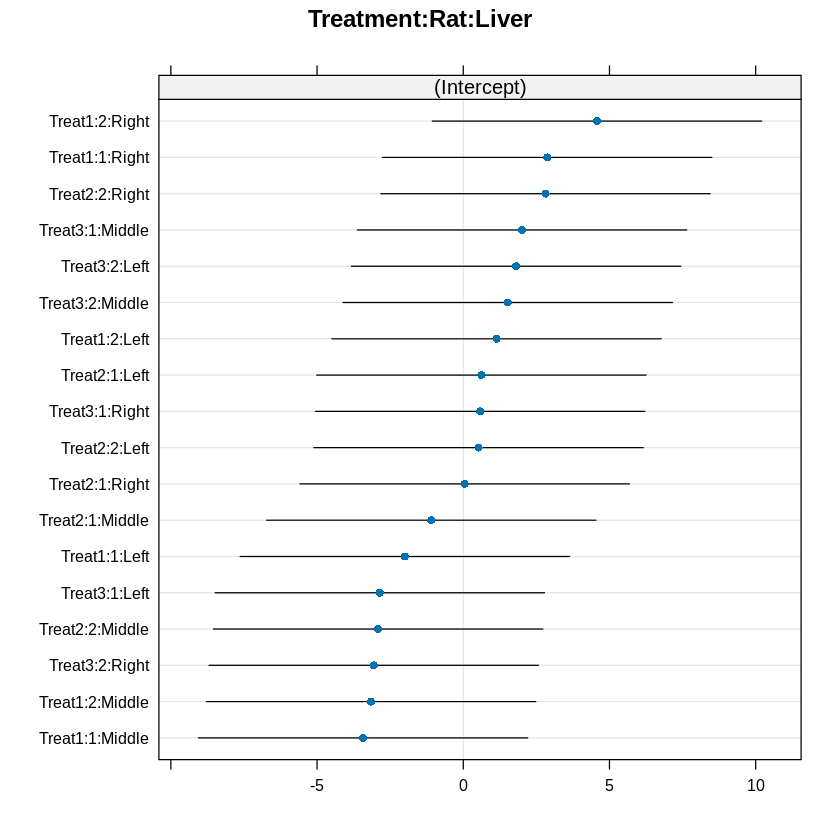

In [104]:
# Load the lattice package for plotting random effects
library(lattice)

# Extract and plot random effects with confidence intervals
# This plot shows the variation of Liver within Rat within Treatment
# Confidence intervals overlapping zero indicate non-significant random effects

dotplot(ranef(ModelR, condVar = TRUE))$`Treatment:Rat:Liver`


### ➡️ Interpretation

The plot shows:

* Each point = random effect estimate for each Liver within Rat within Treatment
* Horizontal lines = 95% confidence intervals
* Vertical line at 0 = reference line (no random effect)

__➡️ Statistical Interpretation__

Key Observation: Confidence intervals overlap with zero

This indicates:

* The random effect deviations from the overall mean are small.
* The variation at the Liver level (within Rat and Treatment) is not statistically significant.
* There is no strong evidence that individual Liver units differ substantially beyond random variation.

__➡️ Model Interpretation Conclusion__

Since most confidence intervals overlap zero:

* The random effect variability is relatively low.
* The model may not require a very complex random-effects structure.
* However, keeping the random effect is still statistically appropriate due to the hierarchical experimental design.


__➡️ Interpretation__

__👉 The random effects dotplot shows confidence intervals overlapping zero, indicating no significant variation at the Liver level. This suggests that the random effects contribute limited variability to the model.__

### ✅ Random Effects Plot for Rat within Treatment

__👉 Key Observation: Some confidence intervals do not overlap with zero.__


This code visualizes the random effects of Rats nested within Treatment in the mixed-effects model ModelR.

* `ranef(ModelR, condVar = TRUE)` extracts random effect estimates and their confidence intervals.
* `dotplot()` creates a graphical display.
* $`Treatment:Rat` selects the random effect corresponding to Rat within Treatment.

__Each point represents the deviation of an individual Rat from the overall Treatment mean.__

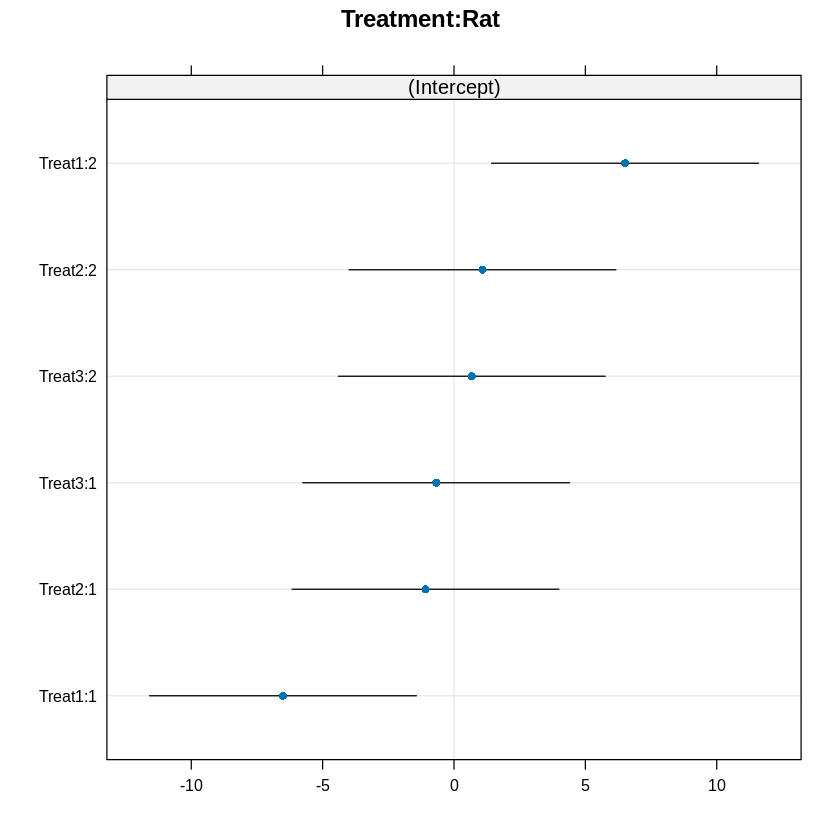

In [105]:
# Load the lattice package for plotting random effects
library(lattice)

# Extract and plot random effects for Rat within Treatment
# condVar = TRUE ensures confidence intervals are displayed

dotplot(ranef(ModelR, condVar = TRUE))$`Treatment:Rat`


### ➡️ Interpretation of the Plot

__➡️ Key Observation: Some confidence intervals do not overlap with zero.__

This indicates:

* Certain Rats have random effects that are significantly different from zero.
* These Rats contribute meaningful variability beyond the average Treatment effect.
* There is significant between-Rat variation within Treatment groups.

__➡️ Statistical Conclusion__

* The random effect of Rat within Treatment is important.
* There is substantial variability among Rats.
* This supports the inclusion of Rat as a random effect in the mixed model.

__➡️ Interpretation__

__👉 Some confidence intervals do not overlap with zero, indicating significant variability between Rats within Treatment. This confirms that the Rat random effect is important in the model.__

### ✅ Estimated Marginal Means (Fixed Effects)

In [106]:
# Load required library
library(emmeans)

# Compute Estimated Marginal Means (EMMs) for Treatment
EMM <- emmeans(ModelR, ~ Treatment)

# Display the estimated marginal means
EMM

 Treatment emmean   SE df lower.CL upper.CL
 Treat1       140 4.71  3      126      155
 Treat2       151 4.71  3      136      166
 Treat3       135 4.71  3      120      150

Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

### ➡️ Interpretation of Estimated Marginal Means (EMMs)

The estimated marginal means (EMMs) represent the adjusted mean Glycogen levels for each Treatment group after accounting for the random effects of Rat and Liver in the mixed-effects model.

__➡️ Estimated Glycogen Levels by Treatment__

| Treatment | Estimated Mean (emmean) | Standard Error (SE) | 95% Confidence Interval |
| --------- | ----------------------- | ------------------- | ----------------------- |
| Treat1    | 140                     | 4.71                | 126 to 155              |
| Treat2    | 151                     | 4.71                | 136 to 166              |
| Treat3    | 135                     | 4.71                | 120 to 150              |


__➡️ Statistical Interpretation__

1. Treat1:
    The estimated mean Glycogen level for Treat1 is 140 units, with a 95% confidence interval ranging from 126 to 155.

2. Treat2:
    The estimated mean Glycogen level for Treat2 is 151 units, which is slightly higher than Treat1. The confidence interval ranges from 136 to 166.

3. Treat3:
    The estimated mean Glycogen level for Treat3 is 135 units, which is slightly lower than Treat1. The confidence interval ranges from 120 to 150.

__➡️ Statistical Conclusion__

__👉 The confidence intervals of all three Treatment groups overlap substantially, indicating that the differences between Treatment means are not statistically significant.
This result is consistent with the earlier ANOVA result (p = 0.197), which showed no significant Treatment effect.__

In [107]:
# Optional: Pairwise comparisons between Treatment levels
pairs(EMM)

 contrast        estimate   SE df t.ratio p.value
 Treat1 - Treat2   -10.50 6.66  3  -1.577  0.3787
 Treat1 - Treat3     5.33 6.66  3   0.801  0.7282
 Treat2 - Treat3    15.83 6.66  3   2.378  0.1862

Degrees-of-freedom method: kenward-roger 
P value adjustment: tukey method for comparing a family of 3 estimates 

### ➡️ Interpretation of Pairwise Comparisons Between Treatment Levels

The pairwise comparisons test whether the mean Glycogen levels differ significantly between each pair of Treatment groups, using Tukey adjustment to control for multiple comparisons.

__➡️ Results Summary__

| Comparison       | Difference (Estimate) | p-value | Interpretation  |
| ---------------- | --------------------- | ------- | --------------- |
| Treat1 vs Treat2 | −10.50                | 0.3787  | Not significant |
| Treat1 vs Treat3 | 5.33                  | 0.7282  | Not significant |
| Treat2 vs Treat3 | 15.83                 | 0.1862  | Not significant |

__➡️ Statistical Interpretation__

1. Treat1 vs Treat2:
    The mean Glycogen level in Treat2 is estimated to be 10.50 units higher than Treat1. However, this difference is not statistically significant (p = 0.3787 > 0.05).

2. Treat1 vs Treat3:
    The mean Glycogen level in Treat1 is estimated to be 5.33 units higher than Treat3. This difference is also not statistically significant (p = 0.7282 > 0.05).

3. Treat2 vs Treat3:
    The mean Glycogen level in Treat2 is estimated to be 15.83 units higher than Treat3. Although this is the largest difference observed, it is still not statistically significant (p = 0.1862 > 0.05).

__➡️ Interpretation__

__👉 Pairwise comparisons using Tukey adjustment showed no statistically significant differences between any Treatment groups (all p > 0.05). This confirms that Treatment does not significantly affect Glycogen levels.__

In [108]:
# Optional: Confidence intervals for estimated means
confint(EMM)

,Treatment,emmean,SE,df,lower.CL,upper.CL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Treat1,140.5000,4.707165,3,125.5197,155.4803
2,Treat2,151.0000,4.707165,3,136.0197,165.9803
3,Treat3,135.1667,4.707165,3,120.1864,150.1470


### ➡️ Interpretation

The 95% confidence intervals for all Treatment means overlap, indicating no statistically significant differences in Glycogen levels among the treatments.

In [109]:
# Compute the critical value from the t-distribution
# 0.975 corresponds to a 95% two-sided confidence interval (alpha = 0.05)
# df = 3 represents the degrees of freedom from the mixed model

qt(0.975, df = 3)


[1] 3.182446

### ➡️ Interpretation

The value 3.182446 is the critical t-value from the t-distribution with 3 degrees of freedom for a 95% confidence interval.

__➡️ Interpretation__

The critical value 3.182 indicates how many standard errors away from the mean are needed to capture 95% of the sampling distribution, given only 3 degrees of freedom.

Because df is small:
* The t-value is large
* Confidence intervals are wider
* Statistical tests have lower power

### ✅ Model Selection Using REML and ML
👉 Note __REML setting True of False__


In [110]:
# Load required library
library(lme4)

#-----------------------------------------------------------------------------------------------------
# Model Selection in Linear Mixed Models
# NOTE:
# REML = TRUE  → Used for estimating variance components (final model estimation)
# REML = FALSE → Used for comparing models with different fixed effects (Model selection)
#-------------------------------------------------------------------------------------------------------

# Model 1: Full model with Treatment and two nested random effects
# Random effects:
# Rat nested within Treatment
# Liver nested within Rat and Treatment
ModelR1 <- lmer(Glycogen ~ Treatment +
                  (1 | Treatment:Rat) +
                  (1 | Treatment:Rat:Liver),
                REML = TRUE,
                data = Rats)

# Model 2: Reduced model with only Rat nested within Treatment
# REML = TRUE version (not suitable for fixed-effect comparison)
ModelR2_REML <- lmer(Glycogen ~ Treatment +
                       (1 | Treatment:Rat),
                     REML = TRUE,
                     data = Rats)

# Model 2: Same model but using Maximum Likelihood (REML = FALSE)
# Required for comparing models differing in fixed effects
ModelR2 <- lmer(Glycogen ~ Treatment +
                  (1 | Treatment:Rat),
                REML = FALSE,
                data = Rats)

# Model 3: Null model (no Treatment effect)
# Used to test whether Treatment improves model fit
ModelR3 <- lmer(Glycogen ~ 1 +
                  (1 | Treatment:Rat),
                REML = FALSE,
                data = Rats)

#-------------------------------------------------------------------------------------------------------
# Compare models using Akaike Information Criterion (AIC)
# Lower AIC indicates better model fit
#-------------------------------------------------------------------------------------------------------

AIC(ModelR1, ModelR2_REML, ModelR2, ModelR3)

#-------------------------------------------------------------------------------------------------------
# IMPORTANT NOTE:
# - Use REML = TRUE for final model estimation
# - Use REML = FALSE for comparing models with different fixed effects
#-------------------------------------------------------------------------------------------------------

,df,AIC
,<dbl>,<dbl>
ModelR1,6,231.6213
ModelR2_REML,5,232.2911
ModelR2,5,245.9404
ModelR3,3,248.4366




__➡️ Statistical Explanation__

__➡️ REML vs ML in Model Selection__

| Method       | Use                                                        |
| ------------ | ---------------------------------------------------------- |
| REML = TRUE  | Best for estimating variance components                    |
| REML = FALSE | Required for comparing models with different fixed effects |
| AIC          | Lower value indicates better model                         |



### ➡️ Interpretation  of Model Selection Using AIC

The Akaike Information Criterion (AIC) is used to compare competing models. A lower AIC value indicates a better balance between model fit and model complexity.

__➡️ Model Comparison Table__

| Model        | df | AIC        | Interpretation              |
| ------------ | -- | ---------- | --------------------------- |
| ModelR1      | 6  | **231.62** | Best model                  |
| ModelR2_REML | 5  | 232.29     | Slightly worse than ModelR1 |
| ModelR2      | 5  | 245.94     | Much worse fit              |
| ModelR3      | 3  | 248.44     | Worst model                 |


__➡️ Statistical Interpretation__

__➡️ 1. Best Model: ModelR1__

ModelR1 has the lowest AIC value (231.62), indicating the best fit among all models.

This model includes:
* Fixed effect: Treatment
* Random effects:
    * Rat nested within Treatment → (1 | Treatment:Rat)
    * Liver nested within Rat and Treatment → (1 | Treatment:Rat:Liver)

This means that both sources of random variability (Rat and Liver) are important and should be included in the model.

__➡️ 2. Comparison with ModelR2_REML__

ModelR2_REML has a slightly higher AIC (232.29), meaning removing the Liver random effect slightly worsens the model fit.

This indicates that:

* Liver-level variability contributes important information
* Including Liver nested within Rat improves the model

__➡️ 3. Comparison with ModelR2 and ModelR3__

ModelR2 (AIC = 245.94) and ModelR3 (AIC = 248.44) have much higher AIC values, indicating poorer model fit.

This shows:

* Removing random effects worsens the model
* Removing Treatment (ModelR3) makes the model worst

__➡️ Final Statistical Conclusion__

The most appropriate model is:

    ModelR1 <- lmer(Glycogen ~ Treatment +
    (1 | Treatment:Rat) +
    (1 | Treatment:Rat:Liver),
    REML = TRUE,
    data = Rats)

#### 👉 This model properly accounts for the nested experimental design and provides the best explanation of Glycogen variability.

### ✅ Correct Model Comparison Strategy
__👉 1. To compare random effects structure → use REML = TRUE__

In [111]:
AIC(ModelR1, ModelR2_REML)

,df,AIC
,<dbl>,<dbl>
ModelR1,6,231.6213
ModelR2_REML,5,232.2911


__👉 2. To compare fixed effects structure → use REML = FALSE__

In [112]:
AIC(ModelR2, ModelR3)


,df,AIC
,<dbl>,<dbl>
ModelR2,5,245.9404
ModelR3,3,248.4366


### ✅ Maximum Likelihood Comparison of Nested Mixed Models

__👉 ANOVA Comparison Tests__

    anova(ModelR1, ModelR2_REML)

Tests whether adding the Liver random effect significantly improves the model.

__Hypothesis:__

* __H₀ (Null hypothesis):__ The Liver random effect is not needed; it does not improve the model.
* __H₁ (Alternative hypothesis):__ The Liver random effect improves the model fit.

In [113]:
# Load required library
library(lme4)

#-------------------------------------------------------------------------------------------------------
# Maximum Likelihood Model Comparison using ANOVA
# NOTE:
# Model comparison using ANOVA requires REML = FALSE
# when comparing models with different fixed effects.
#-------------------------------------------------------------------------------------------------------

# Compare ModelR1 and ModelR2_REML
# These models differ in random effects structure (Liver effect included vs excluded)
# Ideally, both models should be fitted using REML = TRUE for random effects comparison

anova(ModelR1, ModelR2_REML)


refitting model(s) with ML (instead of REML)



,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ModelR2_REML,5,245.9404,253.8580,-117.9702,235.9404,NA,NA,NA
ModelR1,6,245.2705,254.7716,-116.6353,233.2705,2.669834,1,0.1022667


### ➡️ Statistical Interpretation

__➡️ Results Summary__

| Model        | Parameters (npar) | AIC        | logLik  | Chi-square | df | p-value    |
| ------------ | ----------------- | ---------- | ------- | ---------- | -- | ---------- |
| ModelR2_REML | 5                 | 245.94     | −117.97 | –          | –  | –          |
| ModelR1      | 6                 | **245.27** | −116.64 | 2.67       | 1  | **0.1023** |


__➡️ 1. Likelihood Ratio Test Result__

    The Chi-square statistic is 2.67 with 1 degree of freedom and a p-value = 0.1023.

__➡️ 2. Significance Decision__

    Since the p-value (0.1023) is greater than the significance level of 0.05, we fail to reject the null hypothesis.

__➡️ 3. Conclusion about Liver Random Effect__

    This means that adding the Liver random effect does not significantly improve the model fit.

__➡️ Interpretation__

__👉 Although ModelR1 has a slightly lower AIC (245.27) compared to ModelR2 (245.94), the improvement is not statistically significant. This suggests that the variation between liver parts within rats is relatively small compared to other sources of variability.__

__👉 ANOVA Comparison Tests__

    anova(ModelR2, ModelR3)

Tests whether Treatment significantly improves the model.

__Hypothesis:__

* __H₀ (Null hypothesis):__ Treatment has no effect on Glycogen levels.
* __H₁ (Alternative hypothesis):__ Treatment significantly improves the model and affects Glycogen levels.

In [114]:
#-------------------------------------------------------------------------------------------------------
# Compare ModelR2 and ModelR3 using Maximum Likelihood
# These models differ in fixed effects (Treatment included vs excluded)
# Therefore, REML must be set to FALSE
#-------------------------------------------------------------------------------------------------------

anova(ModelR2, ModelR3)

,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ModelR3,3,248.4366,253.1871,-121.2183,242.4366,NA,NA,NA
ModelR2,5,245.9404,253.8580,-117.9702,235.9404,6.496197,2,0.038848


### ➡️ Statistical Interpretation

__➡️ Results Summary__

| Model                    | Parameters (npar) | AIC        | logLik  | Chi-square | df | p-value    |
| ------------------------ | ----------------- | ---------- | ------- | ---------- | -- | ---------- |
| ModelR3 (No Treatment)   | 3                 | 248.44     | −121.22 | –          | –  | –          |
| ModelR2 (With Treatment) | 5                 | **245.94** | −117.97 | 6.50       | 2  | **0.0388** |


__➡️ 1. Likelihood Ratio Test Result__
    The Chi-square statistic is 6.50 with 2 degrees of freedom, and the p-value = 0.0388.

__➡️ 2. Significance Decision__
    Since the p-value (0.0388) is less than 0.05, we reject the null hypothesis.

__➡️ 3. Conclusion about Treatment Effect__
    This indicates that including Treatment significantly improves the model fit.

__➡️ Model Fit Interpretation Using AIC__

* Model with Treatment (ModelR2): AIC = 245.94
* Model without Treatment (ModelR3): AIC = 248.44

Lower AIC confirms that the model including Treatment provides a better fit.

There is a significant difference so Model R2 is the better model.

__➡️ Final Overall Model Conclusion (Based on All Tests)__

* Treatment effect → Significant (p = 0.0388) ✔
* Rat random effect → Important ✔
* Liver random effect → Not strongly significant (p = 0.102), but acceptable to keep due to nested design


__👉 ModelR2 is the best model base on the maximum likelihood comparison (anova())__

### ✅ Final Model (ModelR2) Using REML and Post-Hoc Analysis

👉 __ModelR2__ is the __best model__ base on the maximum likelihood comparison (anova())

👉 Next we run it with __REML is true__ to better fit the __random effects__.

👉 Inspect the __REML criterion__ at convergence is __smaller__; __ModelR was 219.6__.


In [115]:
# Load required libraries
library(lme4)       # For fitting linear mixed models
library(lmerTest)   # For p-values and ANOVA tables
library(emmeans)    # For estimated marginal means and pairwise comparisons

#-------------------------------------------------------------------------------------------------------
# Step 1: Fit the Final Model Using REML
# ModelR2 was selected as the best model based on maximum likelihood comparison.
# Now refit using REML = TRUE for unbiased estimation of random effects.
#-------------------------------------------------------------------------------------------------------

ModelR2_REML <- lmer(Glycogen ~ Treatment +
                       (1 | Treatment:Rat),
                     REML = TRUE,
                     data = Rats)

In [116]:
#-------------------------------------------------------------------------------------------------------
# Step 2: Display Model Summary
# Shows fixed effects, random effects, variance components,
# and REML criterion at convergence.
#-------------------------------------------------------------------------------------------------------

summary(ModelR2_REML)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: Glycogen ~ Treatment + (1 | Treatment:Rat)
   Data: Rats

REML criterion at convergence: 222.3

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-1.65504 -0.65585  0.09145  0.54711  2.18876 

Random effects:
 Groups        Name        Variance Std.Dev.
 Treatment:Rat (Intercept) 38.9     6.237   
 Residual                  32.5     5.701   
Number of obs: 36, groups:  Treatment:Rat, 6

Fixed effects:
                Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)      140.500      4.707   3.000  29.848 8.26e-05 ***
TreatmentTreat2   10.500      6.657   3.000   1.577    0.213    
TreatmentTreat3   -5.333      6.657   3.000  -0.801    0.482    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr) TrtmT2
TretmntTrt2 -0.707       
TretmntTrt3 -0.707  0.500

In [117]:
#-------------------------------------------------------------------------------------------------------
# Step 3: ANOVA Table for Fixed Effect (Treatment)
# Tests whether Treatment significantly affects Glycogen levels.
#-------------------------------------------------------------------------------------------------------

anova(ModelR2_REML)

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
Treatment,190.3823,95.19117,2,3,2.928959,0.197099


In [118]:
#-------------------------------------------------------------------------------------------------------
# Step 4: Estimated Marginal Means (EMMs)
# Provides adjusted mean Glycogen levels for each Treatment.
#-------------------------------------------------------------------------------------------------------

EMM <- emmeans(ModelR2_REML, ~ Treatment)

# Display estimated marginal means
EMM

 Treatment emmean   SE df lower.CL upper.CL
 Treat1       140 4.71  3      126      155
 Treat2       151 4.71  3      136      166
 Treat3       135 4.71  3      120      150

Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

In [119]:
#-------------------------------------------------------------------------------------------------------
# Step 5: Pairwise Comparisons (Unadjusted p-values)
# No correction for multiple testing
#-------------------------------------------------------------------------------------------------------

pairs(EMM, adjust = "none")

 contrast        estimate   SE df t.ratio p.value
 Treat1 - Treat2   -10.50 6.66  3  -1.577  0.2128
 Treat1 - Treat3     5.33 6.66  3   0.801  0.4816
 Treat2 - Treat3    15.83 6.66  3   2.378  0.0978

Degrees-of-freedom method: kenward-roger 

In [120]:
#-------------------------------------------------------------------------------------------------------
# Step 6: Pairwise Comparisons with FDR Correction
# Controls false discovery rate for multiple comparisons
#-------------------------------------------------------------------------------------------------------

pairs(EMM, adjust = "fdr")

 contrast        estimate   SE df t.ratio p.value
 Treat1 - Treat2   -10.50 6.66  3  -1.577  0.3192
 Treat1 - Treat3     5.33 6.66  3   0.801  0.4816
 Treat2 - Treat3    15.83 6.66  3   2.378  0.2933

Degrees-of-freedom method: kenward-roger 
P value adjustment: fdr method for 3 tests 

### ✅ Power Analysis for Random Effect (Rat)

__👉 Power Analysis__

This simulation estimates the statistical power to detect the Liver random effect nested within Rat and Treatment.

* 100 datasets are simulated based on the fitted model
* Each dataset is analyzed using two models:
* Full model: includes Liver random effect
* Reduced model: excludes Liver random effect
* A likelihood ratio test compares the models
* Power is calculated as the proportion of simulations where the p-value is less than 0.05

__👉 Statistical Meaning of Power__

$$
\text{Power} = \frac{\text{Number of significant tests}}{\text{Total simulations}}
$$


In [121]:
#-------------------------------------------------------------------------------------------------------
# Power Analysis for Random Effect: Rat
# This simulation estimates the statistical power to detect
# the nested Liver random effect within Rat and Treatment.
#-------------------------------------------------------------------------------------------------------

# Load required library
library(lme4)

# Number of simulations
nSim <- 100
# Set seed for reproducibility
set.seed(123)

# Store p-values from likelihood ratio tests
pVal <- numeric(100)

#-------------------------------------------------------------------------------------------------------
# Step 1: Simulate response data from both models
# ModelR1 includes Liver random effect
# ModelR2 excludes Liver random effect
#-------------------------------------------------------------------------------------------------------
Sim1 <- simulate(ModelR1, 100)
Sim2 <- simulate(ModelR2, 100)

#-------------------------------------------------------------------------------------------------------
# Step 2: Loop through each simulation
# Fit both models and compare using likelihood ratio test
#-------------------------------------------------------------------------------------------------------
for(i in 1:100){

# Fit full model (includes Liver random effect)
ModelR1 <- lmer(Sim1[,i] ~ Treatment + (1|Treatment:Rat) + (1|Treatment:Rat:Liver),
                REML = F, data = Rats)

# Fit reduced model (excludes Liver random effect)
ModelR2 <- lmer(Sim2[,i] ~ Treatment + (1|Treatment:Rat),
                REML = F, data = Rats)

 # Extract p-value from likelihood ratio test
    pVal[i] <- anova(ModelR1, ModelR2)$`Pr(>Chisq)`[2]
 }

#-------------------------------------------------------------------------------------------------------
# Step 3: Calculate statistical power
# Power = proportion of simulations where p < 0.05
#-------------------------------------------------------------------------------------------------------

power_estimate <- sum(pVal < 0.05) / nSim

# Display power
power_estimate


boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) 

[1] 0.34

### ➡️Interpretation in your Glycogen mixed model experiment
__Power = 0.34 → Very low power__


__➡️ Power = 0.34__ indicates:

* The experiment has very low ability to detect Treatment effect
* Even if Treatment truly affects Glycogen, the model will detect it only 34% of the time
* The study is severely underpowered

__➡️ Statistical conclusion__

Because power is very low:
* A non-significant result does NOT mean Treatment has no effect
* It may simply mean the study lacks sufficient data to detect the effect
* This is called an inconclusive result, not evidence of no effect.

__➡️ Power Interpretation Guide__


| Power      | Interpretation       |
| ---------- | -------------------- |
| ≥ 0.80     | Good power ✔         |
| 0.60–0.79  | Moderate power       |
| 0.40–0.59  | Low power            |
| **< 0.40** | **Very low power ❌** |


__P👉 ower = 0.34 indicates very low statistical power, meaning the study has a high probability of missing a true Treatment effect, and therefore the results are inconclusive.__

### ✅ Power Analysis for Fixed Effect (Treatment)

__👉 Interpretation of Power Analysis (Fixed Effect: Treatment)__

This simulation estimates the statistical power to detect the Treatment effect on Glycogen concentration.


* Simulates 100 datasets based on the fitted model that includes Treatment
* Fits two models to each simulated dataset:
   * Full model: includes Treatment
   * Reduced model: excludes Treatment
* Uses likelihood ratio test to compare models
* Calculates power as the proportion of tests where p-value < 0.05

__👉 Statistical Meaning__

$$
\text{Power} = \frac{\text{Number of significant Treatment tests}}{\text{Total simulations}}
$$
    
 __👉 Power represents the probability of correctly detecting the Treatment effect when it truly exists.__

In [122]:
#-------------------------------------------------------------------------------------------------------
# Power Analysis for Fixed Effect: Treatment
# This simulation estimates the statistical power to detect
# the Treatment effect using likelihood ratio tests.
#-------------------------------------------------------------------------------------------------------

# Load required library
library(lme4)

# Set seed for reproducibility
set.seed(123)

# Number of simulations
# nSim <- 100

# Vector to store p-values
pVal <- numeric(100)

#-------------------------------------------------------------------------------------------------------
# Step 1: Simulate response data from the full model
# ModelR2 includes Treatment effect
#-------------------------------------------------------------------------------------------------------

Sim1 <- simulate(ModelR2, 100)
Sim3 <- simulate(ModelR3, 100)

#-------------------------------------------------------------------------------------------------------
# Step 2: Loop through each simulation
# Compare model with Treatment vs model without Treatment
#-------------------------------------------------------------------------------------------------------
for(i in 1:100){

# Full model (includes Treatment effect)
ModelR1 <- lmer(Sim2[,i] ~ Treatment + (1|Treatment:Rat) ,
                REML = F, data = Rats)

# Reduced model (excludes Treatment effect)
ModelR2 <- lmer(Sim3[,i] ~ 1 + (1|Treatment:Rat),
                REML = F, data = Rats)


# Extract p-value from likelihood ratio test
    pVal[i] <- anova(ModelR1, ModelR2)$`Pr(>Chisq)`[2]
 }

#-------------------------------------------------------------------------------------------------------
# Step 3: Calculate statistical power
# Power = proportion of significant tests (p < 0.05)
#-------------------------------------------------------------------------------------------------------
power_treatment <- sum(pVal < 0.05) / nSim

# Display power estimate
power_treatment


boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) 

[1] 0.68

### ➡️ Power conclusion interpretation

__Power = 0.68__
    
* No effect detected
* Power too low, inconclusive

__➡️ Interpretation:__

__Power of 0.68__ means:

* Only 68% chance of detecting true effect
* Recommended power is ≥ 0.80

Therefore: Study may fail to detect real treatment effect.

__👉 Conclusion:__
* Results are inconclusive due to low power.

### ✅ Comparing Model Definitions

### 📌 Correct Model Definition (Nested Linear Mixed Model)

In [123]:
# Correct Model Specification (Nested Random Effects)
# Treatment = Fixed effect
# Rat nested within Treatment = Random effect
# Liver nested within Rat and Treatment = Random effect
# Display model summary

summary(ModelR)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: Glycogen ~ Treatment + (1 | Treatment:Rat) + (1 | Treatment:Rat:Liver)
   Data: Rats

REML criterion at convergence: 219.6

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-1.48212 -0.47263  0.03062  0.42934  1.82935 

Random effects:
 Groups              Name        Variance Std.Dev.
 Treatment:Rat:Liver (Intercept) 14.17    3.764   
 Treatment:Rat       (Intercept) 36.06    6.005   
 Residual                        21.17    4.601   
Number of obs: 36, groups:  Treatment:Rat:Liver, 18; Treatment:Rat, 6

Fixed effects:
                Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)      140.500      4.707   3.000  29.848 8.26e-05 ***
TreatmentTreat2   10.500      6.657   3.000   1.577    0.213    
TreatmentTreat3   -5.333      6.657   3.000  -0.801    0.482    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
     

### ➡️ Interpretation: Correct Model Definition (Nested Linear Mixed Model)

The linear mixed model was fitted using REML with Treatment as a fixed effect and Rat and Liver as nested random effects. The model correctly reflects the hierarchical experimental design, where liver samples are nested within rats and rats are nested within treatments.

### ➡️ 1. Model Fit and Residuals

The REML criterion at convergence is __219.6__, which measures model fit for mixed models. Lower REML values indicate better fit when comparing models with the same fixed effects.

The scaled residuals range from __–1.48__ to __1.83__, with median close to zero (0.031), indicating:

* No strong deviation from model assumptions
* No extreme outliers
* Residuals appear reasonably symmetric

This suggests that the model fits the data adequately.

### ➡️ 2. Random Effects Interpretation (Variance Components)

The model includes two nested random effects:

__➡️ (a) Rat within Treatment:__ (1 | Treatment:Rat)

* Variance = 36.06
* Standard deviation = 6.005

This indicates substantial variability in Glycogen concentration between rats within the same treatment. This confirms that rats differ biologically and must be treated as a random effect.

This is the __largest source of variability__, meaning rat-to-rat differences are important.

__➡️ (b) Liver within Rat and Treatment:__ (1 | Treatment:Rat:Liver)

* Variance = 14.17
* Standard deviation = 3.764

This represents variability between liver parts within the same rat. This variability may arise due to:

* Biological variation within liver regions
* Measurement variation

This confirms that subsampling variability exists and is correctly accounted for.

__➡️ (c) Residual Variance__

* Variance = 21.17
* Standard deviation = 4.601

This represents unexplained variability after accounting for Treatment, Rat, and Liver effects.

### ➡️ 3. Fixed Effects Interpretation (Treatment Effect)
__➡️ Intercept (Treat1 baseline)__

Estimate = 140.5, p < 0.001

This represents the mean Glycogen concentration for Treatment 1 (reference group). It is highly statistically significant, indicating that the baseline Glycogen level is clearly different from zero.

__➡️ Treatment 2 vs Treatment 1__

Estimate = +10.5, p = 0.213

This indicates that Glycogen concentration in Treatment 2 is higher than Treatment 1 by 10.5 units on average. However, this difference is not statistically significant (p > 0.05).

__➡️ Treatment 3 vs Treatment 1__

Estimate = –5.33, p = 0.482

This indicates that Glycogen concentration in Treatment 3 is lower than Treatment 1 by 5.33 units on average. However, this difference is also not statistically significant (p > 0.05).

### ➡️ 4. Statistical Conclusion (Treatment Effect)

__👉 There is no statistically significant evidence that Treatment affects Glycogen concentration at the 5% significance level. Although Treatment 2 shows higher mean Glycogen and Treatment 3 shows lower mean Glycogen compared to Treatment 1, these differences are not large enough relative to variability between rats__.

### 📌 Wrong Model Definition

In [124]:
summary(ModelR_wrong)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: Glycogen ~ 1 + (1 | Treatment/Rat/Liver)
   Data: Rats

REML criterion at convergence: 234.7

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-1.48343 -0.42637 -0.00421  0.41130  1.81917 

Random effects:
 Groups              Name        Variance Std.Dev.
 Liver:Rat:Treatment (Intercept) 14.17    3.764   
 Rat:Treatment       (Intercept) 36.06    6.005   
 Treatment           (Intercept) 42.75    6.538   
 Residual                        21.17    4.601   
Number of obs: 36, groups:  
Liver:Rat:Treatment, 18; Rat:Treatment, 6; Treatment, 3

Fixed effects:
            Estimate Std. Error      df t value Pr(>|t|)   
(Intercept)  142.222      4.651   2.000   30.58  0.00107 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

### ➡️  ❌ Interpretation: Wrong Model Definition

__➡️ 1. Model specification problem__

The wrong model was defined as:

    Glycogen ~ 1 + (1 | Treatment/Rat/Liver)
         
This expands internally to:

       Glycogen ~ 1 + (1 | Treatment) + (1 | Treatment:Rat) + (1 | Treatment:Rat:Liver)
       
__➡ Key mistake:__

Treatment is incorrectly included as a random effect instead of a fixed effect.

In this experiment:

* Treatment is a controlled experimental factor
* It must be modeled as a fixed effect, not random

Correct model should be:

    Glycogen ~ Treatment + (1 | Treatment:Rat) + (1 | Treatment:Rat:Liver)
    
__➡️ 2. Fixed effects interpretation (Wrong model)__

__➡ Fixed effects:__

Estimate = 142.222

Meaning:

* Only one fixed effect exists: the overall intercept
* This represents the grand mean Glycogen level across all treatments

Major problem:

* The model does NOT estimate Treatment effects
* Therefore, it cannot answer the main research question:

❌ Does Treatment affect Glycogen?

__➡️3. Random effects interpretation__

__➡ Random effects:__
* Treatment variance = 42.75
* Treatment:Rat variance = 36.06
* Treatment:Rat:Liver variance = 14.17
* Residual variance = 21.17

__➡ Interpretation:__

This model assumes:
* Treatments are randomly sampled from a population
* Variation between treatments is treated as random noise

This is incorrect because:
* Treatments were deliberately assigned by the researcher
* We want to compare treatments, not treat them as random variability

__➡️ 4. Missing treatment comparison__

Wrong model output does NOT provide:

    TreatmentTreat2

    TreatmentTreat3

Therefore:
* No treatment effect estimates
* No hypothesis test for treatment
* No scientific conclusion about treatment effect possible

__➡️ 5. REML criterion comparison__

* __Wrong model:__ REML = 234.7
* __Correct model:__ REML = 219.6

__➡ Interpretation:__

__Lower REML__ indicates better model fit.

Therefore:

✔ Correct model fits data better

❌ Wrong model fits worse

__➡️ 6. Scientific interpretation problem__

* __Wrong model assumes:__ Treatment is random
* __Correct interpretation should be:__ Treatment __is fixed__ experimental factor

Because:

* Treatments were controlled by experimenter
* We want to compare their means

__➡️ 7. Statistical conclusion__

❌ Wrong model cannot test treatment effect

❌ Wrong model gives incorrect experimental interpretation

❌ Wrong model has poorer fit

❌ Wrong model answers wrong scientific question

__➡️ 8. Correct conclusion statement__

👉 The model is incorrectly specified because Treatment is included as a random effect rather than a fixed effect. As a result, the model estimates only the overall mean and does not estimate or test treatment effects. Since Treatment is a controlled experimental factor, it must be included as a fixed effect. The incorrect model also has a higher REML value, indicating poorer model fit. Therefore, this model is inappropriate for testing treatment differences in Glycogen concentration.

__➡️ 9. Summary comparison table__

| Feature                         | Correct Model    | Wrong Model      |
| ------------------------------- | ---------------- | ---------------- |
| Treatment modeled as            | Fixed effect ✔   | Random effect ❌  |
| Estimates treatment differences | Yes ✔            | No ❌             |
| Tests treatment significance    | Yes ✔            | No ❌             |
| Answers research question       | Yes ✔            | No ❌             |
| REML value                      | Lower (better) ✔ | Higher (worse) ❌ |
| Scientific validity             | Correct ✔        | Incorrect ❌      |


### 📌 Wrong Model Definition (ModelR_wrong2)

In [125]:
summary(ModelR_wrong2)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: Glycogen ~ Treatment + (1 | Rat/Liver)
   Data: Rats

REML criterion at convergence: 227.1

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-1.91171 -0.71277 -0.03182  0.71589  2.52546 

Random effects:
 Groups    Name        Variance  Std.Dev. 
 Liver:Rat (Intercept) 1.146e-07 0.0003385
 Rat       (Intercept) 2.061e+01 4.5395756
 Residual              4.248e+01 6.5173452
Number of obs: 36, groups:  Liver:Rat, 6; Rat, 2

Fixed effects:
                Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)      140.500      3.721   1.451  37.762 0.003790 ** 
TreatmentTreat2   10.500      2.661  32.000   3.946 0.000407 ***
TreatmentTreat3   -5.333      2.661  32.000  -2.004 0.053541 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr) TrtmT2
TretmntTrt2 -0.358       
TretmntTrt3 -0.358  0.500
optimizer (n

### ➡️ ❌ Interpretation: Wrong Model Definition (ModelR_wrong2)
__➡️ 1. Model specification problem__

The model was specified as:

    (1 | Rat/Liver)
    
This expands to:

    (1 | Rat) + (1 | Rat:Liver)
    
__➡❗ Key mistake:__

This model assumes:
* Rats are independent of Treatment
* Liver pieces are nested within Rat only
* Treatment structure is ignored in nesting

But in the real experiment:
* Rats are nested within Treatment
* Liver pieces are nested within Rat AND Treatment

Correct structure should be:

    (1 | Treatment:Rat) + (1 | Treatment:Rat:Liver)
    
__➡️ 2. Evidence from random effects output__

Wrong model output:

| Groups     |  Variance |
|------------|-----------|
|Liver:Rat   |   ~ 0     |
|Rat         |  20.61    |
|Residual    |  42.48    |


__➡ Interpretation:__

__➡ Rat variance is large__

    Variance = 20.61
    
This means:

* There is substantial variability between rats
* Rat contributes significantly to Glycogen variation

__➡ Liver variance is essentially zero__

    Variance = 1.146e-07 ≈ 0

This indicates:

* Model cannot correctly estimate Liver variability
* This happens because nesting structure is incorrectly specified

This is confirmed by warning:

    boundary (singular) fit
    
Singular fit means:

* Model structure is incorrect or over-simplified
* Some variance components cannot be estimated properly

__➡️ 3. Residual variance interpretation__

    Residual variance = 42.48
    
This is much larger than in correct model:

Correct model residual variance: 21.17

This means:

❌ Wrong model fails to explain variability properly

❌ Variability is incorrectly pushed into residual

Correct model explains variability better.

__➡️ 4. Fixed effects interpretation__

    TreatmentTreat2 = 10.500, p = 0.000407 ***
    TreatmentTreat3 = -5.333, p = 0.0535
    
This suggests:

* Treatment 2 significantly increases Glycogen
* Treatment 3 is marginally non-significant

BUT this result is unreliable because:
* Random structure is incorrect
* Variance components are misestimated
* Standard errors are incorrect

Therefore fixed effect tests may be biased.

__➡️ 5. REML comparison__

| Model         | REML  |
| ------------- | ----- |
| Correct model | 219.6 |
| Wrong Model 2 | 227.1 |

Lower REML is better.

Therefore:

✔ Correct model fits better

❌ Wrong Model 2 fits worse

__➡️ 6. Singular fit warning interpretation__

    boundary (singular) fit

This indicates:

* Model is over-simplified or mis-specified
* Some variance components estimated as zero
* Model does not represent true experimental design

__👉 This confirms incorrect random effect structure.__

### ✅  Summary comparison

| Feature                 | Correct Model | Wrong Model 2 |
| ----------------------- | ------------- | ------------- |
| Nesting structure       | Correct ✔     | Incorrect ❌   |
| Rat nested in Treatment | Yes ✔         | No ❌          |
| Liver nested correctly  | Yes ✔         | No ❌          |
| Singular fit            | No ✔          | Yes ❌         |
| Variance estimation     | Correct ✔     | Incorrect ❌   |
| REML                    | Lower ✔       | Higher ❌      |
| Reliable inference      | Yes ✔         | No ❌          |


<div class="alert alert-block alert-info" style="margin-top: 20px">
    
### THANK YOU ...!

Ms.MRUNALINI (Data Science Trainer)
📧 mrunalini0107@gmail.com
📍 Mumbai–400095